# $\pi$ estimation using Monte Carlo integration + analytical explanation
* Check lecture 10, the circle example.

### The connection between the code from lecture 10 and Monte Carlo integration is as next:
#### The main idea that we are counting points where N is the total number of points.
- Define C(r) (the function of the circle):
- $C(r) = 1$  if  $r^2<1$  (inside)
- $C(r) = 0$  if  $r^2>1$  (outside)
- **Remember that $C(r)$ inside the integral is intuitivly an arbitrary continuous function with `r2` values between 1 and 0.**
- $p(r) = \frac{1}{1-0}$ is the uniform distribution used in the code
- This is a full circle area
$$A_c = \int^{1}_{-1} \int^{\sqrt{1-x^2}}_{-\sqrt{1-x^2}} dy dx = \int C (r)*p(r) dr \approx \frac{\sum C(r)}{N} = \frac{1+1+1+0+0+1+1+1+1+1+0+0+0+1+0+......}{N} $$

- Define S(r) (the function of the square):
- $S(r) = 1$ always as it contains the circle.
$$A_s = \int S(r)*p(r) dr \approx \frac{\sum S(r)}{N} = \frac{1+1+1+1+1+1+1+1+1+1+1+1+1+1......N}{N} = 1$$

#### **Then:**

$$ \frac{A_c}{A_s} = \frac{\pi}{4} \approx \frac{\sum C(r)}{\sum S(r)} \approx \frac{\sum C(r)}{N} $$

- In general (from the circle equation) : $\int^{1}_{0} \int^{\sqrt{1-x^2}}_{-\sqrt{1-x^2}} dy dx$
- But, we used C(r) to represent the counting method (The statistical method)

In [1]:
import numpy as np
import scipy.stats as stats
import pylab as plt
import astropy.visualization.hist as histogram
import astroML.stats

## I just estimated $\pi$ here through the volume of a sphere.

Estimate of pi is 3.138 for 10000 draws with fractional error 0.0011435771552648654.


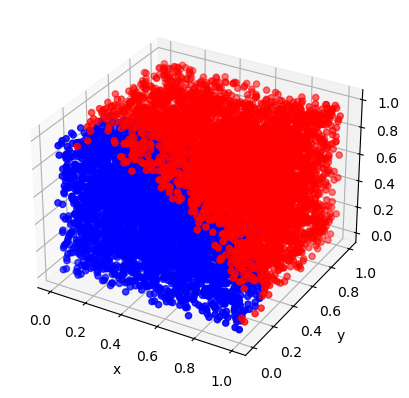

In [2]:
M = 10000
x = stats.uniform(0,1).rvs(M) # M random draws between 0 and 1
y = stats.uniform(0,1).rvs(M) 
z = stats.uniform(0,1).rvs(M)

r2 = x**2+y**2 + z**2 

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(x[r2>1], y[r2>1], z[r2>1] ,'.', color = 'red' )
ax.scatter(x[r2<1], y[r2<1], z[r2<1] ,'go', color= 'blue')


#ax.axis([0, 1, 0, 1], aspect='equal');
plt.xlabel('x')
plt.ylabel('y');
    
# V_cube = r^3, V_sphere1/8 = pi*r^3/6
piEst = 6 * np.sum(r2 < 1) / M # pi = 6V_circ/V_cube
print("Estimate of pi is {0} for {1} draws with fractional error {2}.".format(piEst, M, 
                                                                              np.abs((np.pi-piEst)/np.pi)))

### Time to get your hands dirty! Planning a telescope observation


Let's build your first Markov Chain! 

You are a real astronomer (not a theory guy like me) and are planning an expensive observational campaign. You want to know how likely it is that tomorrow night will be clear given the weather tonight (clear or cloudy). The key piece of information here is that the weather tomorrow depends on the weather today. From past history, you know that:

$$p({\rm clear \; tomorrow} \, |\,  {\rm cloudy \; today}) = 0.5,$$

which means that

$$p({\rm cloudy \; tomorrow} \, |\, {\rm cloudy \; today}) = 0.5.$$

We also have

$$p({\rm cloudy \; tomorrow} \, |\, {\rm clear \; today}) = 0.1,$$

which means that

$$p({\rm clear \; tomorrow} \, |\, {\rm clear \; today}) = 0.9.$$


- We can start with the sky conditions today and make predictions going forward more and more into the future.
- This will look like a big decision tree. 
- After enough days, we'll reach equilibrium probabilities that have to do with the mean weather statistics (ignoring seasons) and we'll arrive at

$$p({\rm clear}) = 0.83,$$

and 

$$p({\rm cloudy}) = 0.17.$$

You get the same answer for day $N$ as day $N+1$ and it doesn't matter whether it was clear or cloudy on the day that you started. The steps that we have taken in this process are, indeed, a **MARKOV CHAIN**.

Here is an illustration of this process:

![image.png](https://miro.medium.com/max/416/1*frksGjINf5oTjx7WL81U3w.png)

In [3]:
import numpy as np
import scipy.stats as stats
import pylab as plt
import astropy.visualization.hist as histogram
import astroML.stats

#### Tasks

- Start off on a cloud day. 
- Implement your weather forecast based on the above probabilities
- Run your simulator for N days (with $N\gtrsim 10^4$)
- Prepare a plot with the number of days on the x axis and the cumulative fraction of, say, sunny days over the number of days so far on the y axis.

In [ ]:
# psr = probability sunny tomorrow | rainy today   ----> cloudy=rainy
# 0 -->  not clear
# 1 -->  clear

psr = 0.5
prr = 0.5
prs = 0.1
pss = 0.9
N = 100000


wlist = [0,0]  #  weather list starts on a cloudy day

clear = 0   # clear days counter
cumfracclear = [] # cumulative fraction of clear days
cleardays = []

cloudy = 0
cloudydays = []
cumfraccloudy = []

for n in range(1,N):
    
    
  if wlist[n] == 1:
    expectation = np.random.choice([0,1], p= [prs,pss])
    clear += 1
    cumfracclear.append(clear/n)
    cleardays.append(n)
  elif wlist[n] == 0:
    expectation = np.random.choice([0,1], p= [prr,psr])
    cloudy += 1 
    cumfraccloudy.append(cloudy/(n))
    cloudydays.append(n)
  wlist.append(expectation)   

* This is called a **trace-plot**, showing how our estimate of $p(\mathrm{clear})$ evolves as the chain samples.

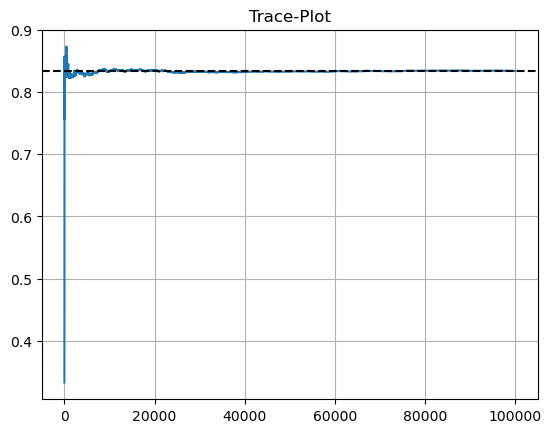

In [5]:
plt.plot(cleardays,cumfracclear)
plt.axhline(np.median(cumfracclear), ls = 'dashed',color = 'black')
plt.title('Trace-Plot')
plt.grid();

- Prepare a histogram of the above plot. This reveals the distribution of $p(\mathrm{clear})$.


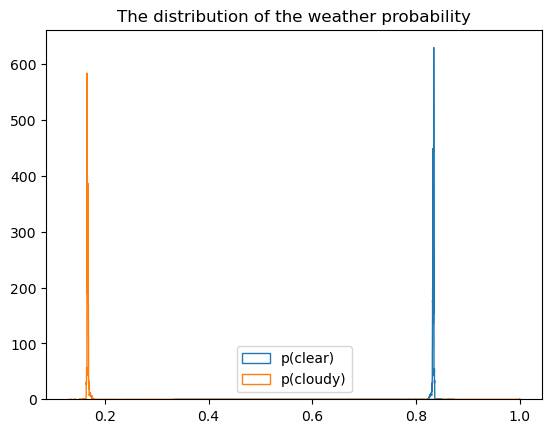

In [6]:
histogram(cumfracclear, histtype= 'step', bins='freedman', density= True,label = 'p(clear)')
histogram(cumfraccloudy, histtype= 'step', bins='freedman', density= True,label = 'p(cloudy)')
plt.legend()
plt.title('The distribution of the weather probability');

- Use a summary statistics to determine the most likely value and an error on our estimate.


In [7]:
print(astroML.stats.mean_sigma(cumfracclear)) # The regular standard deviation
print(astroML.stats.sigmaG(cumfracclear))     # The standard deviation here takes care of the outliers
print(astroML.stats.mean_sigma(cumfraccloudy))
astroML.stats.mean_sigma(cumfracclear)[0] + astroML.stats.mean_sigma(cumfraccloudy)[0]

(np.float64(0.8332014986855999), np.float64(0.003393728689906045))
0.0012131502457127877
(np.float64(0.16707721596833286), np.float64(0.011664785701334618))


np.float64(1.0002787146539327)


**Important:** 
- In MCMC the process must be **stationary** which basically means that the chain statistics look the same no matter which chunk you look at, e.g. first half, second half, or every other point, etc.  
- Obviously that isn't going to be the case in the early steps of the chain. In our example above, after some time the process was stationary, but not in the first few days.
- So, there is a **burn-in** phase that needs to be discarded. How one determines the number of early steps to discard as burn-in is tricky, but ***you should always start with a traceplot of your samples!***


#### Tasks

- In the above example, experiment with chopping off different numbers of initial points as burn-in.



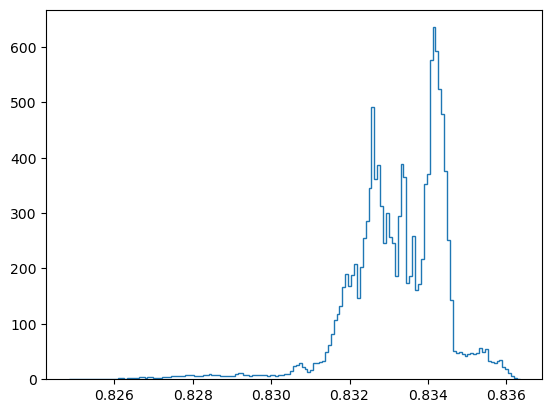

In [8]:
histogram(cumfracclear[2000:], histtype= 'step', bins='freedman', density= True);

In [9]:
print(astroML.stats.mean_sigma(cumfracclear[2000:]))
print(astroML.stats.sigmaG(cumfracclear[2000:]))

(np.float64(0.8332415851340267), np.float64(0.0012817412955932605))
0.0011920256173315845


### Come back for this later:(indeed, MCMC samples combine many walkers). Which is from `S10_sunnycloudy.ipynb`


#### (Optional, not examinable) Finance

- Redo the same for the Markovian process describing the stock market (see above in this notebook). If you've written your code well, this should require minor modifications.
![](https://upload.wikimedia.org/wikipedia/commons/thumb/9/95/Finance_Markov_chain_example_state_space.svg/400px-Finance_Markov_chain_example_state_space.svg.png)


### I have started on a stagnant market

In [14]:
# 2 is for bear
# 1 is for bull
# 0 is for stagnant
p22 = 0.8
p12 = 0.15
p02 = 0.05

p11 = 0.9
p21 = 0.075
p01 = 0.025

p00 = 0.5
p10 = 0.25
p20 = 0.25

N = 100000


mlist = [0,0]  

bear = 0   
cumfracbear = [] 
bearlist = []

bull = 0   
cumfracbull = [] 
bulllist = []

st = 0   
cumfracst = [] 
stlist = []


for n in range(1,N):
    
    
  if mlist[n] == 2:
    expectation = np.random.choice([0,1,2], p= [p02,p12,p22])
    bear += 1
    cumfracbear.append(bear/n)
    bearlist.append(n)
  elif mlist[n] == 1:
    expectation = np.random.choice([0,1,2], p= [p01,p11,p21])
    bull += 1
    cumfracbull.append(bull/n)
    bulllist.append(n)
  elif mlist[n] == 0:
    expectation = np.random.choice([0,1,2], p= [p00,p10,p20])
    st += 1
    cumfracst.append(st/n)
    stlist.append(n)
  mlist.append(expectation)   

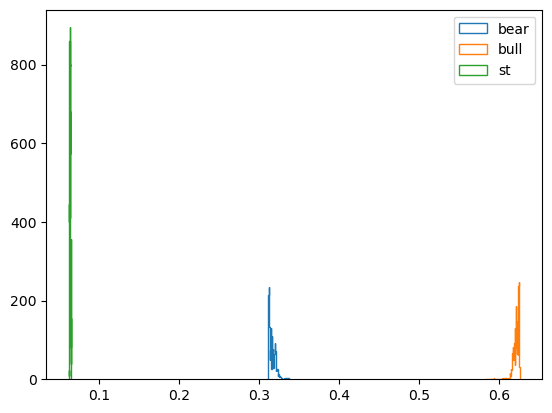

In [16]:
histogram(cumfracbear[2000:], histtype= 'step', bins='freedman', density= True, label = 'bear')
histogram(cumfracbull[2000:], histtype= 'step', bins='freedman', density= True, label = 'bull')
histogram(cumfracst[2000:], histtype= 'step', bins='freedman', density= True, label = 'st')
plt.legend();